In this notebook, we focus on several dynamics of time series
* auto correlation
* vol change
* seasonality
* regime switch

For each property, we hope to have a way to examine it automatically. And find the optimal parameters automatically. 

In [1]:
import sys

sys.path.append("../../../src/")
from sts.data.dapi import Ticker
from sts.plots.time_series_plots import plot_multi_time_series
import numpy as np
import pandas as pd
from sts.quant.indicators.trend import get_trend_score
from sts.quant.indicators.volatility import get_vol_atr_scaled
from sts.optimization.corr_max import get_optimal_horizon_max_corr
from sts.quant.indicators.utils import resample
from statsmodels.graphics.tsaplots import plot_pacf

In [2]:
ticker = Ticker("SPY")
df = ticker.history(period="10Y")

/home/yuqing42/miniconda3/envs/sts/lib/python3.12/site-packages/yfinance/utils.py:771: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')


# Auto correlation

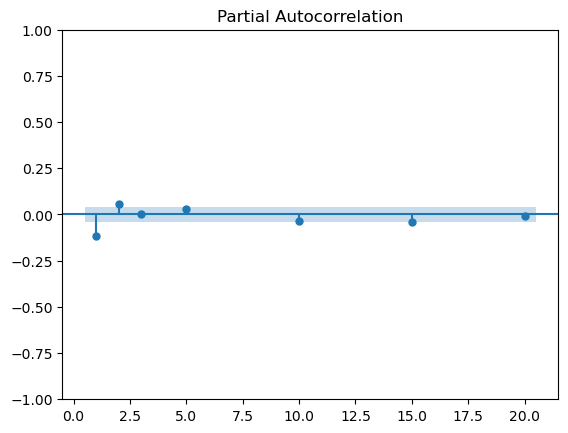

In [28]:
_ = plot_pacf(np.log(df["Close"]).diff().dropna(), lags=[1, 2, 3, 5, 10, 15, 20])

betta via regression, since the mean and variance calculation is fully known. Such seasonality can also be founded with linear regression. The only thing is how to automate this and auto detect some abnormal behavior (corresponding to regime change)